In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel

import arviz as az

/home/taliyah/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the 2026 dataset: https://memory.psych.upenn.edu/Data_Archive#2026

In [3]:
# Get data
data = pd.read_csv('data/Exp3_AllData.csv', header=0, sep=',')
data.head()
data = data[~np.isnan(data["Output_Rank"])]

# Convert to ints
data["Listnum"] = data["Listnum"].astype(int)
data["Spatial_Input_Order"] = data["Spatial_Input_Order"].astype(int)
data["Temporal_Input_Position"] = data["Temporal_Input_Position"].astype(int)
data["Length"] = data["Length"].astype(int)
data["Serial_Pos_Encoded"] = data["Serial_Pos_Encoded"].astype(int)
data["Output_Rank"] = data["Output_Rank"].astype(int)

# Filter only for varied data
data = data[data["List_Type"] == 'Varied']

# Filter separately for the spatial and temporal conditions
spatial_data = data[data["Order_Type"] == 'Spatial']
temporal_data = data[data["Order_Type"] == 'Temporal']

# Only use a fraction of the data
train_percent = 1.00
spatial_data = spatial_data.sample(n=int(spatial_data.shape[0]*train_percent))
temporal_data = temporal_data.sample(n=int(temporal_data.shape[0]*train_percent))

spatial_data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "main_input_order": data.Spatial_Input_Order.values,
    "other_input_order": data.Temporal_Input_Position.values,
    # Results
    "recall_order": data.Spatial_Recall_Order.values,
}

temporal_data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "main_input_order": data.Temporal_Input_Position.values,
    "other_input_order": data.Spatial_Input_Order.values,
    # Results
    "recall_order": data.Spatial_Recall_Order.values,
}

First, we will create a model for the spatial condition trials.

In [7]:
# Compile spatial model
spatial_model = CmdStanModel(stan_file="stan/varied_model.stan")

In [8]:
# Sample spatial model
spatial_fit = spatial_model.sample(data=spatial_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
# print(spatial_fit.diagnose())

09:53:54 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 2:   3%|█▋                                                           | 100/3500 [00:01<00:49, 68.45it/s, (Warmup)]


chain 1:   3%|█▋                                                           | 100/3500 [00:01<00:55, 61.65it/s, (Warmup)]

chain 2:   6%|███▍                                                         | 200/3500 [00:03<00:50, 65.54it/s, (Warmup)]


chain 4:   6%|███▍                                                         | 200/3500 [00:03<00:51, 63.95it/s, (Warmup)]

chain 1:   9%|█████▏                                                       | 300/3500 [00:04<00:45, 69.95it/s, (Warmup)]

chain 3:   9%|█████▏                                                       | 300/3500 [0


09:54:51 - cmdstanpy - INFO - CmdStan done processing.


In [9]:
print(spatial_fit.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [10]:
spatial_fit_data = az.from_cmdstanpy(spatial_fit)
spatial_summary = az.summary(data=spatial_fit_data, var_names=["sigma_base_recall", "beta_other_order"], round_to="none")

# Display sampling data
display(spatial_summary)

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
r_hat_sum = 0
for r_hat in spatial_summary['r_hat']:
    num += 1
    r_hat_sum += r_hat
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R_hat Values Past Threshold:", num_past)

# Display how good R_hat values are
print("Average R_hat Value:", r_hat_sum / num)
print("R_hat score:", (1.01 - (r_hat_sum / num)) * 10000)

draws_df = spatial_fit.draws_pd()
display(draws_df.head())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_base_recall,3.250769,0.289774,2.714905,3.797188,0.002030,0.002990,20181.509809,7504.853587,1.000422
beta_other_order[0],0.523309,0.293952,-0.044560,1.049006,0.002083,0.003015,19805.703758,7542.514296,1.000667
beta_other_order[1],0.223588,0.294605,-0.328050,0.763724,0.002056,0.003086,20390.832331,7598.784831,1.000903
beta_other_order[2],0.189977,0.295089,-0.366011,0.733384,0.002091,0.003099,19767.021366,7519.086113,1.000270
beta_other_order[3],0.012516,0.293252,-0.548605,0.547791,0.002057,0.003006,20181.781458,7316.972109,1.000345
beta_other_order[4],-0.217389,0.293488,-0.754572,0.341204,0.002045,0.002966,20461.785125,7685.135079,1.000168
beta_other_order[5],-0.507710,0.291669,-1.067577,0.028017,0.002037,0.003006,20431.667930,7818.539764,1.000742
beta_other_order[6],-0.380087,0.294696,-0.922192,0.182032,0.002079,0.003080,19956.979925,7346.976805,1.000377
beta_other_order[7],-0.417742,0.293737,-0.983791,0.116118,0.002040,0.003042,20532.355772,7627.164947,1.000577
beta_other_order[8],-0.105058,0.293968,-0.675820,0.419886,0.002065,0.002993,20112.657459,7843.427187,1.000441


Number of 13 R_hat Values Past Threshold: 0
Average R_hat Value: 1.0004936264717381
R_hat score: 95.06373528261891


,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,recall_order_gen[19430],recall_order_gen[19431],recall_order_gen[19432],recall_order_gen[19433],recall_order_gen[19434],recall_order_gen[19435],recall_order_gen[19436],recall_order_gen[19437],recall_order_gen[19438],recall_order_gen[19439]
0,1.0,1.0,1.0,-33087.718,0.805726,0.699322,3.0,7.0,0.0,33094.730,...,12.0,5.0,2.0,4.0,12.0,6.0,1.0,3.0,2.0,7.0
1,1.0,2.0,2.0,-33086.583,1.000000,0.699322,3.0,7.0,0.0,33092.298,...,8.0,11.0,11.0,12.0,5.0,7.0,5.0,9.0,1.0,7.0
2,1.0,3.0,3.0,-33085.786,0.930435,0.699322,3.0,7.0,0.0,33092.870,...,12.0,8.0,1.0,10.0,12.0,10.0,3.0,2.0,1.0,9.0
3,1.0,4.0,4.0,-33084.843,0.972271,0.699322,3.0,7.0,0.0,33090.217,...,12.0,7.0,5.0,11.0,11.0,8.0,1.0,1.0,6.0,12.0
4,1.0,5.0,5.0,-33089.401,0.571240,0.699322,3.0,7.0,0.0,33097.539,...,12.0,10.0,2.0,2.0,10.0,12.0,5.0,9.0,9.0,6.0


Total Data Accuracy: 0.4490971757806472
Total Model Accuracy: 0.19447069293687946


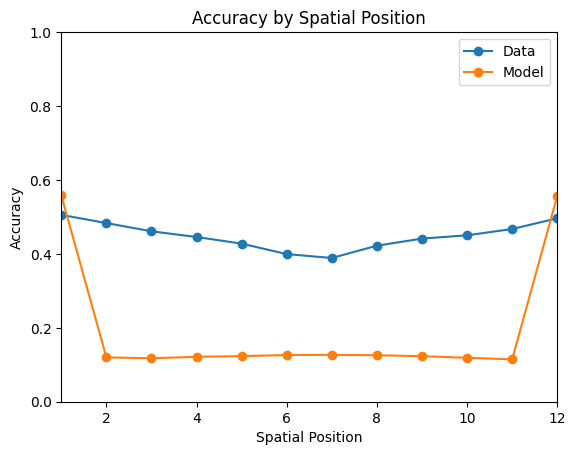

In [11]:
# Check that the spatial model has the same accuracy as the true results
spatial_main_input_order = spatial_data_dict["main_input_order"]
spatial_recall_order = spatial_data_dict["recall_order"]
spatial_recall_order_gen = spatial_fit.stan_variable("recall_order_gen")

data_correct_recall = (spatial_main_input_order == spatial_recall_order)
data_accuracy = np.mean(data_correct_recall)

model_correct_recall = (spatial_main_input_order == spatial_recall_order_gen)
model_accuracies = np.mean(model_correct_recall, axis=1)
model_accuracies_mean = np.mean(model_accuracies)

print("Total Data Accuracy:", data_accuracy)
print("Total Model Accuracy:", model_accuracies_mean)

# Check the accuracy of each main input
positions = range(1, 12+1)
data_pos_accuracies = np.zeros(12)
for i in positions:
    input_indexes = (spatial_main_input_order == i)
    data_pos_accuracies[i-1] = np.mean(data_correct_recall[input_indexes])

model_pos_accuracy_means = np.zeros(12)
for i in positions:
    input_indexes = (spatial_main_input_order == i)
    model_pos_accuracies = np.mean(model_correct_recall[:,input_indexes], axis=1)
    model_pos_accuracy_means[i-1] = np.mean(model_pos_accuracies)

# Plot results
plt.plot(positions, data_pos_accuracies, "o-", label="Data")
plt.plot(positions, model_pos_accuracy_means, "o-", label="Model")
plt.xlabel("Spatial Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Spatial Position")
plt.xlim((1, 12))
plt.ylim((0, 1))
plt.legend()
plt.show()


Next, we will create a model for the temporal condition trials.

In [4]:
# Compile temporal model
temporal_model = CmdStanModel(stan_file="stan/varied_model.stan")

In [5]:
# Sample temporal model
temporal_fit = temporal_model.sample(data=temporal_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
print(temporal_fit.diagnose())

10:04:39 - cmdstanpy - INFO - CmdStan start processing
chain 2:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]


chain 4:   0%|                                                                       | 0/3500 [00:00<?, ?it/s, (Warmup)]

chain 2:   3%|█▋                                                           | 100/3500 [00:01<00:49, 68.71it/s, (Warmup)]


chain 1:   3%|█▋                                                           | 100/3500 [00:01<00:58, 58.02it/s, (Warmup)]

chain 2:   6%|███▍                                                         | 200/3500 [00:03<00:51, 63.71it/s, (Warmup)]


chain 1:   6%|███▍                                                         | 200/3500 [00:03<00:56, 58.82it/s, (Warmup)]

chain 2:   9%|█████▏                                                       | 300/3500 [0


10:05:33 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
temporal_fit_data = az.from_cmdstanpy(temporal_fit)
temporal_summary = az.summary(data=temporal_fit_data, var_names=["sigma_base_recall", "beta_other_order"], round_to="none")

# Display sampling data
display(temporal_summary)

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
r_hat_sum = 0
for r_hat in temporal_summary['r_hat']:
    num += 1
    r_hat_sum += r_hat
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R_hat Values Past Threshold:", num_past)

# Display how good R_hat values are
print("Average R_hat Value:", r_hat_sum / num)
print("R_hat score:", (1.01 - (r_hat_sum / num)) * 10000)

draws_df = temporal_fit.draws_pd()
display(draws_df.head())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma_base_recall,3.598204,0.284889,3.074581,4.145301,0.001950,0.003296,21328.837511,6351.590775,0.999796
beta_other_order[0],0.995791,0.292902,0.430747,1.525545,0.001938,0.003325,22811.112894,6875.452883,0.999866
beta_other_order[1],0.302911,0.291575,-0.241040,0.864733,0.002003,0.003374,21174.344361,6546.678244,0.999790
beta_other_order[2],0.284442,0.291244,-0.284447,0.806090,0.001988,0.003361,21452.163128,7045.732136,0.999866
beta_other_order[3],-0.266760,0.290976,-0.810331,0.294295,0.001992,0.003331,21343.455597,6624.705424,1.000159
beta_other_order[4],-0.512942,0.287247,-1.048010,0.024169,0.001942,0.003329,21859.633722,6946.871534,0.999962
beta_other_order[5],-0.527273,0.290470,-1.059070,0.029533,0.001973,0.003376,21702.406494,6537.529577,0.999891
beta_other_order[6],-0.613354,0.289397,-1.158322,-0.071156,0.001984,0.003351,21299.011729,6455.617208,0.999943
beta_other_order[7],-0.524426,0.290473,-1.050831,0.040559,0.001971,0.003379,21724.449593,6444.795376,0.999754
beta_other_order[8],-0.196513,0.290041,-0.753804,0.332690,0.001989,0.003276,21285.340509,6946.664656,0.999834


Number of 13 R_hat Values Past Threshold: 0
Average R_hat Value: 0.9998776838026449
R_hat score: 101.22316197355153


,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,recall_order_gen[19430],recall_order_gen[19431],recall_order_gen[19432],recall_order_gen[19433],recall_order_gen[19434],recall_order_gen[19435],recall_order_gen[19436],recall_order_gen[19437],recall_order_gen[19438],recall_order_gen[19439]
0,1.0,1.0,1.0,-34890.314,0.935505,0.619919,3.0,7.0,0.0,34898.132,...,8.0,2.0,3.0,5.0,11.0,4.0,12.0,8.0,10.0,9.0
1,1.0,2.0,2.0,-34890.258,0.982688,0.619919,3.0,7.0,0.0,34895.873,...,7.0,2.0,8.0,5.0,12.0,9.0,3.0,12.0,5.0,12.0
2,1.0,3.0,3.0,-34886.348,0.990466,0.619919,3.0,7.0,0.0,34893.602,...,3.0,12.0,6.0,5.0,4.0,6.0,11.0,12.0,12.0,6.0
3,1.0,4.0,4.0,-34889.205,0.716729,0.619919,3.0,7.0,0.0,34895.415,...,1.0,3.0,4.0,11.0,1.0,9.0,12.0,7.0,12.0,12.0
4,1.0,5.0,5.0,-34888.608,0.850776,0.619919,3.0,7.0,0.0,34896.304,...,1.0,1.0,1.0,1.0,8.0,10.0,11.0,12.0,9.0,11.0


Total Data Accuracy: 0.28772056175729205
Total Model Accuracy: 0.1852569216523484


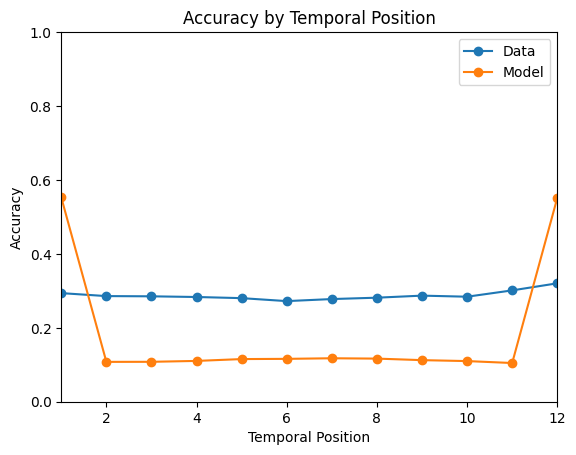

In [7]:
# Check that the temporal model has the same accuracy as the true results
temporal_main_input_order = temporal_data_dict["main_input_order"]
temporal_recall_order = temporal_data_dict["recall_order"]
temporal_recall_order_gen = temporal_fit.stan_variable("recall_order_gen")

data_correct_recall = (temporal_main_input_order == temporal_recall_order)
data_accuracy = np.mean(data_correct_recall)

model_correct_recall = (temporal_main_input_order == temporal_recall_order_gen)
model_accuracies = np.mean(model_correct_recall, axis=1)
model_accuracies_mean = np.mean(model_accuracies)

print("Total Data Accuracy:", data_accuracy)
print("Total Model Accuracy:", model_accuracies_mean)

# Check the accuracy of each main input
positions = range(1, 12+1)
data_pos_accuracies = np.zeros(12)
for i in positions:
    input_indexes = (temporal_main_input_order == i)
    data_pos_accuracies[i-1] = np.mean(data_correct_recall[input_indexes])

model_pos_accuracy_means = np.zeros(12)
for i in positions:
    input_indexes = (temporal_main_input_order == i)
    model_pos_accuracies = np.mean(model_correct_recall[:,input_indexes], axis=1)
    model_pos_accuracy_means[i-1] = np.mean(model_pos_accuracies)

# Plot results
plt.plot(positions, data_pos_accuracies, "o-", label="Data")
plt.plot(positions, model_pos_accuracy_means, "o-", label="Model")
plt.xlabel("Temporal Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Temporal Position")
plt.xlim((1, 12))
plt.ylim((0, 1))
plt.legend()
plt.show()
